In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [38]:
data = pd.read_csv("C:/Users/Durosimi/PROJECTS/Parkinson/data/processed/features_temporal_new.csv")
model = joblib.load("C:/Users/Durosimi/PROJECTS/Parkinson/models/ridge_temporal.pkl")

In [40]:
data.columns

Index(['baseline_updrs', 'subject', 'motor_updrs', 'test_time', 'updrs_lag1',
       'updrs_lag2', 'updrs_roll10', 'delta_lag1', 'updrs_from_baseline',
       'delta_motor_updrs', 'updrs_roll3', 'jitter', 'shimmer', 'hnr', 'rpde',
       'ppe', 'sex'],
      dtype='object')

In [42]:
data["updrs_roll10"] = data.groupby("subject")["motor_updrs"].rolling(window=10, min_periods=1).mean().reset_index(level=0, drop=True)

In [44]:
features = [
    "updrs_lag1",
    "updrs_lag2",
    "updrs_roll10",
    "updrs_roll3",
    "delta_lag1",
    "updrs_from_baseline",
    "jitter",
    "shimmer",
    "hnr",
    "rpde",
    "ppe",
    "sex"
]

X = data[features]
y_true = data["delta_motor_updrs"]

data["y_pred"] = model.predict(X)
data["abs_error"] = np.abs(y_true - data["y_pred"])
data["sq_error"] = (y_true - data["y_pred"]) ** 2


In [46]:
patient_errors = (
    data
    .groupby("subject")
    .agg(
        mae=("abs_error", "mean"),
        rmse=("sq_error", lambda x: np.sqrt(np.mean(x))),
        visits=("abs_error", "count"),
        baseline=("baseline_updrs", "first")
    )
    .reset_index()
)

patient_errors.sort_values("mae").head()


,subject,mae,rmse,visits,baseline
17,18,0.177960,0.336463,123,6.000
15,16,0.437862,0.508980,135,8.939
4,5,0.631127,1.093970,153,31.000
34,35,0.639965,0.799464,162,36.073
5,6,0.977205,1.134237,153,27.883


In [48]:
best_patients = patient_errors.nsmallest(5, 'mae')
worst_patients = patient_errors.nlargest(5, 'mae')

In [50]:
worst_patients

,subject,mae,rmse,visits,baseline
36,37,8.991468,9.959644,137,22.9620
16,17,7.474841,8.561018,141,19.0930
29,30,6.678983,7.733480,123,32.5350
31,32,6.661242,7.522200,98,16.4870
13,14,6.502949,7.614785,133,6.5651


In [52]:
def plot_patient(subject_id):
    p = data[data["subject"] == subject_id]

    plt.figure(figsize=(8,4))
    plt.plot(p["test_time"], y_true[p.index], label="Actual", marker="o")
    plt.plot(p["test_time"], p["y_pred"], label="Predicted", marker="x")
    plt.title(f"Subject {subject_id}")
    plt.xlabel("Time")
    plt.ylabel("Δ Motor UPDRS")
    plt.legend()
    plt.show()


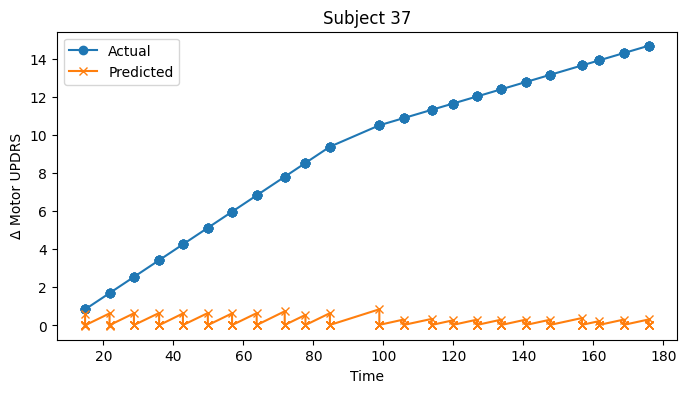

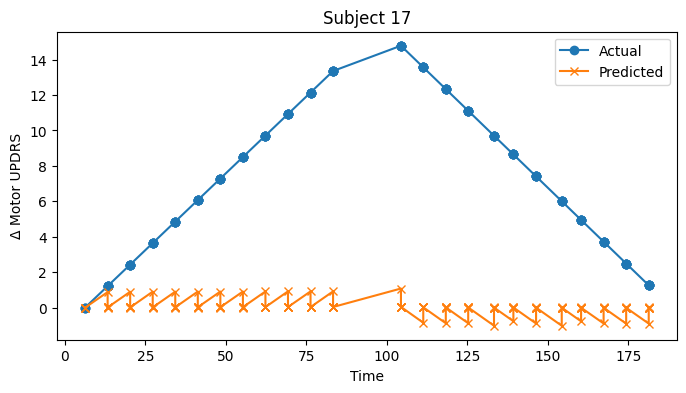

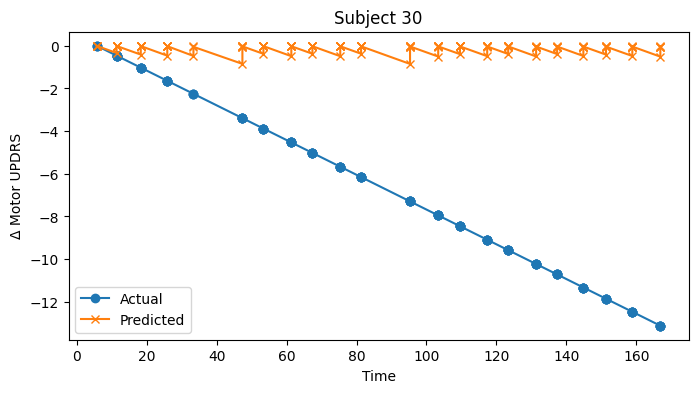

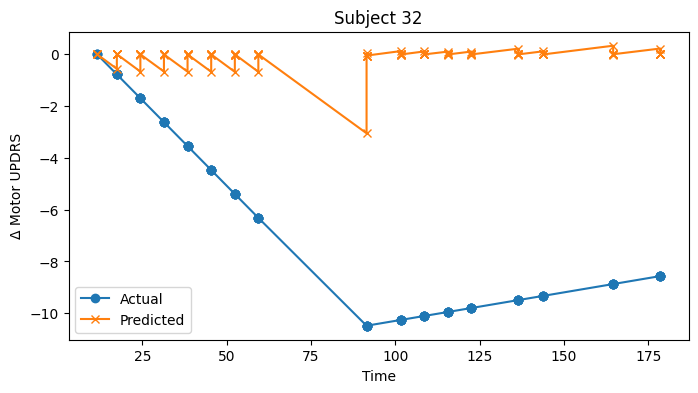

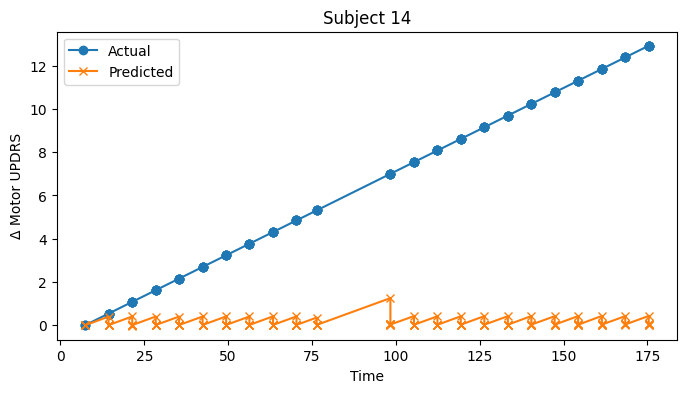

In [54]:
for s in worst_patients["subject"].values:
    plot_patient(s)

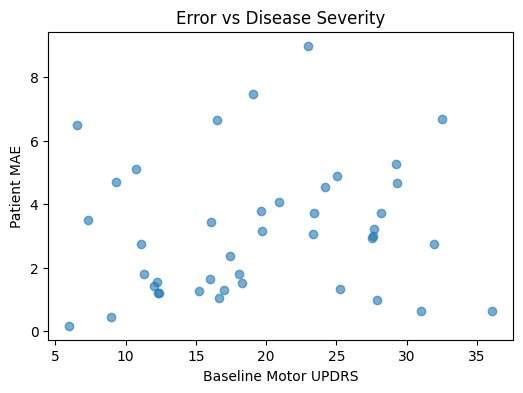

In [56]:
plt.figure(figsize=(6,4))
plt.scatter(
    patient_errors["baseline"],
    patient_errors["mae"],
    alpha=0.6
)
plt.xlabel("Baseline Motor UPDRS")
plt.ylabel("Patient MAE")
plt.title("Error vs Disease Severity")
plt.show()


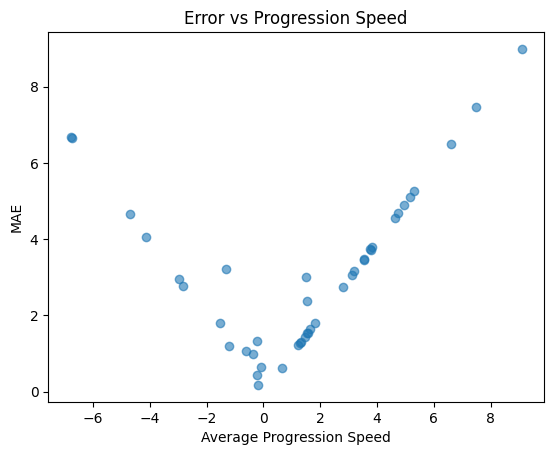

In [58]:
progression_speed = (
    data
    .groupby("subject")
    .agg(speed=("delta_motor_updrs", "mean"))
    .reset_index()
)

merged = patient_errors.merge(progression_speed, on="subject")

plt.scatter(merged["speed"], merged["mae"], alpha=0.6)
plt.xlabel("Average Progression Speed")
plt.ylabel("MAE")
plt.title("Error vs Progression Speed")
plt.show()


In [64]:
patient_errors.to_csv(
    "C:/Users/Durosimi/PROJECTS/Parkinson/reports/tables/patient_error_analysis.csv",
    index=False
)


### The temporal model performs well for patients with smooth progression but struggles for patients with irregular or abrupt disease dynamics, suggesting the need for long-memory or subject-adaptive modeling.